In [1]:
from pandas import concat, read_csv

REGIONS = ('DE', 'DR', 'V')
CSV_COLUMNS = ('I', 'R', 'E', 'A', 'DE', 'DA', 'H', 'M')
NUMERIC_COLUMNS = ('DA', 'H', 'M')
converters = {
    col: lambda value: value.replace(',', '')
    for col in NUMERIC_COLUMNS
}
df = concat(
    (
        read_csv(
            f'R/{region}.csv',
            index_col='I',
            usecols=CSV_COLUMNS,
            converters=converters,
            na_filter=False
        )
        for region in REGIONS
    ),
    keys=REGIONS,
    names=('RE',)
)
df

R   E  A  DE    DA      H      M
RE I                                    
DE 1    T   0  0   8  2947   1425   4611
   1    D   1  0   3  1818      0    650
   1    D   2  0   7  4735    487    308
   1    S   1  0   3  2078   2748      0
   1    S   1  1   3   269   5848    189
...    ..  .. ..  ..   ...    ...    ...
V  491  T  12  1   9  7745     12  12986
   491  D   6  0  10  7838   1433      0
   491  D  12  2   8  8688      0    472
   491  S   2  8   7  1041  11310    256
   491  S   2  7   8  3005   8648    548

[9500 rows x 7 columns]

In [2]:
from string import digits

digit_dict = {'': 0, 'T': 1, 'D': 2, 'S': 3}
for i, d in enumerate(digits, 1):
    digit_dict[d] = i
digit_dict

{'': 0,
 'T': 1,
 'D': 2,
 'S': 3,
 '0': 1,
 '1': 2,
 '2': 3,
 '3': 4,
 '4': 5,
 '5': 6,
 '6': 7,
 '7': 8,
 '8': 9,
 '9': 10}

In [3]:
from pandas import DataFrame
from numpy import uint8

result = {}
for col_name, max_len in df.map(len).max().items():
    for i in range(-max_len, 0):
        result[f'{col_name}{-i}'] = df[col_name].str[i].map(digit_dict).fillna(0).astype(uint8)
result_df = DataFrame(result)
result_df

R1  E2  E1  A2  A1  DE2  DE1  DA5  DA4  DA3  ...  H5  H4  H3  H2  H1  \
RE I                                                 ...                       
DE 1     1   0   1   0   1    0    9    0    3   10  ...   0   2   5   3   6   
   1     2   0   2   0   1    0    4    0    2    9  ...   0   0   0   0   1   
   1     2   0   3   0   1    0    8    0    5    8  ...   0   0   5   9   8   
   1     3   0   2   0   1    0    4    0    3    1  ...   0   3   8   5   9   
   1     3   0   2   0   2    0    4    0    0    3  ...   0   6   9   5   9   
...     ..  ..  ..  ..  ..  ...  ...  ...  ...  ...  ...  ..  ..  ..  ..  ..   
V  491   1   2   3   0   2    0   10    0    8    8  ...   0   0   0   2   3   
   491   2   0   7   0   1    2    1    0    8    9  ...   0   2   5   4   4   
   491   2   2   3   0   3    0    9    0    9    7  ...   0   0   0   0   1   
   491   3   0   3   0   9    0    8    0    2    1  ...   2   2   4   2   1   
   491   3   0   3   0   8    0    9    0    4    1  ...   0   9   7   5   9   

        M5  M4  M3  M2  M1  
RE I                        
DE 1     0   5   7   2   2  
   1     0   0   7   6   1  
   1     0   0   4   1   9  
   1     0   0   0   0   1  
   1     0   0   2   9  10  
...     ..  ..  ..  ..  ..  
V  491   2   3  10   9   7  
   491   0   0   0   0   1  
   491   0   0   5   8   3  
   491   0   0   3   6   7  
   491   0   0   6   5   9  

[9500 rows x 22 columns]

In [4]:
df_numpy = result_df.to_numpy().reshape(-1, 10, 22)
df_0, df_1 = df_numpy[:, :, 0], df_numpy[:, :, 1:]
df_0.shape, df_1.shape

((950, 10), (950, 10, 21))

In [5]:
from pathlib import Path
from tensorflow.random import shuffle
import tensorflow as tf
from tensorflow import gather

image_paths = sorted(map(str, Path().rglob('*.png')))
data_count = len(image_paths)
indices = shuffle(tf.range(data_count))
X_shuffled = gather(image_paths, indices)
y_shuffled_0 = gather(df_0, indices)
y_shuffled_1 = gather(df_1, indices)

train_size = int(data_count * .9)
train_X, val_X = X_shuffled[:train_size], X_shuffled[train_size:]
train_y_0, val_y_0 = y_shuffled_0[:train_size], y_shuffled_0[train_size:]
train_y_1, val_y_1 = y_shuffled_1[:train_size], y_shuffled_1[train_size:]
train_X.shape, train_y_0.shape, train_y_1.shape

I0000 00:00:1774157135.639725      33 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774157141.353241      33 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5555 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti, pci bus id: 0000:06:00.0, compute capability: 8.6


(TensorShape([855]), TensorShape([855, 10]), TensorShape([855, 10, 21]))

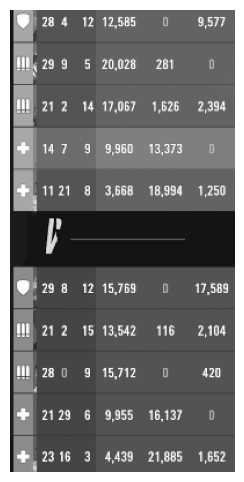

tf.Tensor(
[[ 1  3  9  0  5  2  3  2  3  6  9  6  0  0  0  0  1  0 10  6  8  8]
 [ 2  3 10  0 10  0  6  3  1  1  3  9  0  0  3  9  2  0  0  0  0  1]
 [ 2  3  2  0  3  2  5  2  8  1  7  8  0  2  7  3  7  0  3  4 10  5]
 [ 3  2  5  0  8  0 10  0 10 10  7  1  2  4  4  8  4  0  0  0  0  1]
 [ 3  2  2  3  2  0  9  0  4  7  7  9  2  9 10 10  5  0  2  3  6  1]
 [ 1  3 10  0  9  2  3  2  6  8  7 10  0  0  0  0  1  2  8  6  9 10]
 [ 2  3  2  0  3  2  6  2  4  6  5  3  0  0  2  2  7  0  3  2  1  5]
 [ 2  3  9  0  1  0 10  2  6  8  2  3  0  0  0  0  1  0  0  5  3  1]
 [ 3  3  2  3 10  0  7  0 10 10  6  6  2  7  2  4  8  0  0  0  0  1]
 [ 3  3  4  2  7  0  4  0  5  5  4 10  3  2  9  9  6  0  2  7  6  3]], shape=(10, 22), dtype=uint8)


In [6]:
from tensorflow.data import Dataset, AUTOTUNE
from tensorflow.image import decode_png, resize
from tensorflow.io import read_file
from matplotlib.pyplot import figure, axis, imshow, show
from numpy import array


def preprocess_image(path, label):
    image = decode_png(read_file(path), channels=1)[230:930, 530:1370]
    hud_parts = [
        image[:, :40], image[:, 390:420], image[:, 450:480],
        image[:, 500:530], image[:, 570:640], image[:, 670:740], image[:, 770:]
    ]
    cropped = tf.concat(hud_parts, axis=1)
    resized = resize(cropped, (400, 194)) / 255
    return resized, label


def make_dataset(X, y, shuffle=False, batch_size=32):
    ds = Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(data_count)
    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_X, {'output_1': train_y_0, 'output_2': train_y_1}, True)
val_ds = make_dataset(val_X, {'output_1': val_y_0, 'output_2': val_y_1}, True)
for x_batch, y_batch in train_ds.take(1):
    figure(figsize=(6, 6))
    axis('off')
    imshow(x_batch[0], cmap='gray')
    show()
    y_expanded = tf.expand_dims(y_batch['output_1'], axis=-1)   # (32, 10, 1)
    y_result = tf.concat([y_expanded, y_batch['output_2']], axis=-1)
    print(y_result[0])

- Embedding 고려
- Positional Encoding 고려

build_model에서 모델을 구축할 건데 Input은 흑백 이미지고 shape은 (400, 194, 1)이야. Output 1의 shape은 (10, 4)고 Output 2의 shape은 (10, 21, 11)이야. 한 이미지 내의 여러 기호와 여러 자리의 숫자를 인식하는 모델인데 각 기호 및 숫자는 최대 10 * 22(세로 * 가로) Grid 형태로 구성돼 있어. Output 1은 기호, Output 2은 숫자를 인식해야 해. 각 기호 및 숫자는 절대적인 위치는 변하지만 상대적인 순서 및 위치는 변하지 않아. 이 가로, 세로 순서를 이용하여 출력을 내는 게 중요해. 1열은 기호, 2열 ~ 22열은 숫자인 셈이지. 참고로 각 숫자는 약 9 * 16 픽셀의 크기고 인쇄 폰트 형태야. 각 기호와 숫자는 비어 있을 수도 있기 때문에 Blank를 포함해서 4 클래스와 11 클래스야. 이때 어떤 모델 구조가 가장 적합할까?

In [7]:
from tensorflow.keras.backend import clear_session
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPool2D,
    Reshape,
    Bidirectional,
    LSTM,
    TimeDistributed,
    Dense
)
from tensorflow.keras.losses import SparseCategoricalCrossentropy


def build_model():
    inputs = Input((400, 194, 1))

    x = Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = MaxPool2D((2, 2))(x)

    x = Conv2D(64, 3, padding='same', activation='relu')(x)
    x = MaxPool2D((2, 2))(x)

    x = Conv2D(128, 3, padding='same', activation='relu')(x)
    x = MaxPool2D((2, 2))(x)

    x = Conv2D(256, 3, padding='same', activation='relu')(x)
    x = MaxPool2D((5, 1))(x)

    # (batch, 10, W, C)
    h, w, c = x.shape[1:]

    # row-wise sequence
    x = Reshape((10, w * c))(x)

    x = Bidirectional(LSTM(256, return_sequences=True))(x)

    # output1 (symbol)
    o1 = TimeDistributed(Dense(4), name='output_1')(x)

    # digits branch
    d = Dense(256, 'relu')(x)
    d = Bidirectional(LSTM(256, return_sequences=True))(d)

    d = Dense(21 * 11)(d)
    o2 = Reshape((10, 21, 11), name='output_2')(d)

    return Model(inputs, [o1, o2])


clear_session()
model = build_model()
model.compile(
    'adamw',
    {
        'output_1': SparseCategoricalCrossentropy(True),
        'output_2': SparseCategoricalCrossentropy(True)
    },
    {'output_1': 0.02, 'output_2': 1.98},
    metrics={'output_1': 'sparse_categorical_accuracy', 'output_2': 'sparse_categorical_accuracy'}
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 400, 194,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 400, 194,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 200, 97,   │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 200, 97,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 100, 48,   │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 100, 48,   │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 50, 24,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 50, 24,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 10, 24,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 10, 6144)  │          0 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 10, 512)   │ 13,109,248 │ reshape[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10, 256)   │    131,328 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 10, 512)   │  1,050,624 │ dense_1[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10, 231)   │    118,503 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_1            │ (None, 10, 4)     │      2,052 │ bidirectional[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_2 (Reshape)  │ (None, 10, 21,    │          0 │ dense_2[0][0]     │
│                     │ 11)               │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,799,595 (56.46 MB)

 Trainable params: 14,799,595 (56.46 MB)

 Non-trainable params: 0 (0.00 B)

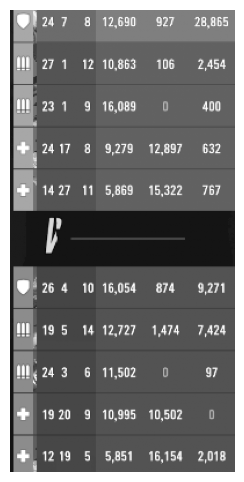

tf.Tensor(
[[ 3  5  0  8  0  9  2  3  7 10  1  0  0 10  3  8  3  9  9  7  6]
 [ 3  8  0  2  2  3  2  1  9  7  4  0  0  2  1  7  0  3  5  6  5]
 [ 3  4  0  2  0 10  2  7  1  9 10  0  0  0  0  1  0  0  5  1  1]
 [ 3  5  2  8  0  9  0 10  3  8 10  2  3  9 10  8  0  0  7  4  3]
 [ 2  5  3  8  2  2  0  6  9  7 10  2  6  4  3  3  0  0  8  7  8]
 [ 3  7  0  5  2  1  2  7  1  6  5  0  0  9  8  5  0 10  3  8  2]
 [ 2  7  0  6  2  5  2  3  8  3  8  0  2  5  8  5  0  8  5  3  5]
 [ 3  5  0  4  0  7  2  2  6  1  3  0  0  0  0  1  0  0  0 10  8]
 [ 2 10  3  1  0 10  2  1 10 10  6  2  1  6  1  3  0  0  0  0  1]
 [ 2  3  2 10  0  6  0  6  9  6  2  2  7  2  6  5  0  3  1  2  9]], shape=(10, 21), dtype=uint8)


In [25]:
from tensorflow.data import Dataset, AUTOTUNE
from tensorflow.image import decode_png, resize
from tensorflow.io import read_file
from matplotlib.pyplot import figure, axis, imshow, show
from numpy import array


def preprocess_image(path, label):
    image = decode_png(read_file(path), channels=1)[230:930, 530:1370]
    hud_parts = [
        image[:, :40], image[:, 390:420], image[:, 450:480],
        image[:, 500:530], image[:, 570:640], image[:, 670:740], image[:, 770:]
    ]
    cropped = tf.concat(hud_parts, axis=1)
    resized = resize(cropped, (400, 194)) / 255
    return resized, label


def make_dataset(X, y, shuffle=False, batch_size=32):
    ds = Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(data_count)
    ds = ds.map(preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_X, train_y_1, True)
val_ds = make_dataset(val_X, val_y_1, True)
for x_batch, y_batch in train_ds.take(1):
    figure(figsize=(6, 6))
    axis('off')
    imshow(x_batch[0], cmap='gray')
    show()
    print(y_batch[0])

In [32]:
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    LayerNormalization,
    Dropout,
    Flatten,
    Reshape,
    MultiHeadAttention,
    Add,
    Layer,
    Lambda
)
from tensorflow.keras.losses import SparseCategoricalCrossentropy


# --------------------------
# Transformer block
# --------------------------
class TransformerBlock(Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn = tf.keras.Sequential([Dense(ff_dim, activation='relu'), Dense(embed_dim)])
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


# --------------------------
# Build OCR model
# --------------------------
def build_model():
    inputs = Input(shape=(400, 194, 1))

    # Backbone CNN
    x = Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)  # 400->200, 194->97

    x = Conv2D(64, 3, padding='same', activation='relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)  # 200->100, 97->48

    x = Conv2D(128, 3, padding='same', activation='relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)  # 100->50, 48->24

    x = Conv2D(256, 3, padding='same', activation='relu')(x)
    x = MaxPooling2D(pool_size=(5, 1))(x)  # 50->10, 24->24

    # Reduce width to 22
    x = Lambda(lambda t: tf.image.resize(t, (10, 22)))(x)

    # x shape ≈ (10, 22, 256)
    
    # Flatten to sequence for Transformer
    seq_len = 10 * 22
    x_seq = Reshape((seq_len, 256))(x)

    # Add positional encoding (simple learned)
    pos_emb = tf.keras.layers.Embedding(input_dim=seq_len, output_dim=256)
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_encoding = pos_emb(positions)
    pos_encoding = tf.expand_dims(pos_encoding, axis=0)  # (1, seq_len, dim)
    
    x_seq = x_seq + pos_encoding

    # Transformer blocks
    for _ in range(4):
        x_seq = TransformerBlock(embed_dim=256, num_heads=4, ff_dim=512)(x_seq)

    # Back to grid
    x_grid = Reshape((10, 22, 256))(x_seq)

    # Symbol head (column 0)
    symbol_feat = x_grid[:, :, 0, :]  # shape: (batch, 10, 256)
    # symbol_out = Dense(4, name='output_1')(symbol_feat)

    # Digit head (columns 1~21)
    digit_feat = x_grid[:, :, 1:, :]  # shape: (batch, 10, 21, 256)
    digit_out = Dense(11, name='output_2')(digit_feat)

    return Model(inputs=inputs, outputs=digit_out)

clear_session()
model = build_model()

In [33]:
model.compile(
    'adamw',
    SparseCategoricalCrossentropy(from_logits=True, ignore_class=0),
    metrics=['sparse_categorical_accuracy']
)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 400, 194, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 400, 194, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 200, 97, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 97, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 100, 48, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 100, 48, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 50, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 10, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 220, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 220, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 220, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 220, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 220, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 220, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 10, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item_1 (GetItem)            │ (None, 10, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_2 (Dense)                │ (None, 10, 21, 11)     │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499,083 (9.53 MB)

 Trainable params: 2,499,083 (9.53 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
from tensorflow.keras.callbacks import EarlyStopping

history = model.fit(
    train_ds,
    epochs=128,
    callbacks=EarlyStopping(patience=16, verbose=1, restore_best_weights=True),
    validation_data=val_ds
)

Epoch 1/128


W0000 00:00:1774161825.262426     101 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1774161826.217738     101 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_126298__.185
I0000 00:00:1774161827.817001    8427 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_88', 1732 bytes spill stores, 1476 bytes spill loads

I0000 00:00:1774161830.965856    8437 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_96', 144 bytes spill stores, 128 bytes spill loads

I0000 00:00:1774161831.635092    8426 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_72', 4 bytes spill stores, 8 bytes spill loads

I0000 00:00:1774161845.548886     101 subprocess_compilation.cc:348

26/27 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 3.3214 - sparse_categorical_accuracy: 0.0866

W0000 00:00:1774161849.745002     102 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1774161850.530527     102 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_126298__.185
I0000 00:00:1774161852.536022    8604 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_96', 144 bytes spill stores, 128 bytes spill loads

I0000 00:00:1774161853.670696    8602 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_88', 32 bytes spill stores, 28 bytes spill loads

I0000 00:00:1774161854.128812    8601 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_88', 1880 bytes spill stores, 1704 bytes spill loads

I0000 00:00:1774161855.880453    8610 subprocess_compilation.cc:348] p

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 914ms/step - loss: 3.3016 - sparse_categorical_accuracy: 0.0868

W0000 00:00:1774161870.728027     103 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1774161870.755025     103 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_127587__.45
W0000 00:00:1774161873.444414     102 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1774161873.469051     102 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_127587__.45
I0000 00:00:1774161874.694850    8811 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_37', 32 bytes spill stores, 28 bytes spill loads

I0000 00:00:1774161875.148339    8807 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_37', 1880 by

27/27 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - loss: 2.7870 - sparse_categorical_accuracy: 0.0919 - val_loss: 2.2737 - val_sparse_categorical_accuracy: 0.1229
Epoch 2/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 2.3095 - sparse_categorical_accuracy: 0.1073 - val_loss: 2.2543 - val_sparse_categorical_accuracy: 0.1229
Epoch 3/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - loss: 2.2967 - sparse_categorical_accuracy: 0.1100 - val_loss: 2.2539 - val_sparse_categorical_accuracy: 0.1229
Epoch 4/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - loss: 2.2924 - sparse_categorical_accuracy: 0.1117 - val_loss: 2.2558 - val_sparse_categorical_accuracy: 0.1229
Epoch 5/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - loss: 2.2843 - sparse_categorical_accuracy: 0.1134 - val_loss: 2.2541 - val_sparse_categorical_accuracy: 0.1229
Epoch 6/128
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - loss: 2.2750 - sparse_categorical_accuracy: 0.1226 - val_loss: 2.2350 - val_sparse_categorical_accuracy: 0.1390
Epoch 7/128


In [59]:
from numpy import unique, insert

losses = []
for y in tuple_data:
    counts = unique(y, return_counts=True)[1][1:]
    r = 1 / counts
    alpha = insert(r / sum(r) * len(counts), 0, 0)
    losses.append(SparseCategoricalFocalCrossentropy(alpha, from_logits=True))
    print(alpha)
len(losses)

[0.         0.99502378 1.00497622]
[0.         1.50020733 0.74968901 0.75010366]
[0.         0.01341114 0.02432201 0.0968016  0.46539233 4.40007292]
[0.         0.90752362 0.93676814 0.96900103 0.99797448 0.97318678
 0.99247902 1.00464989 1.01597627 1.11669263 1.08574814]
[0.00000000e+00 1.51482221e-03 4.58508490e-03 1.85155658e-02
 1.61496879e-01 2.90694382e+00 2.90694382e+00]
[0.         0.36664823 0.57538644 0.67346964 0.73366057 0.93047379
 1.00653432 1.15436905 1.37322712 1.46007152 1.72615932]
[0.         0.02402746 1.97597254]
[0.         1.14230743 1.08658511 1.11235929 1.00677943 0.95600836
 0.81295602 0.86003841 0.8769683  0.96742649 1.17857116]
[0.         0.05640314 1.94359686]
[0.         1.59512328 0.83892895 0.74263315 0.70385335 0.78289207
 0.87809718 0.92215223 1.06692283 1.23469848 1.23469848]
[0.         0.99010431 0.98357615 0.98249648 0.99671971 1.0011793
 1.01710715 0.96867348 1.01136079 1.0419724  1.00681023]
[0.         0.98900154 1.00111626 0.98574825 0.9771765

23